# Data Cleaning & Pre-Processing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# read the dataframe
df = pd.read_csv('TMDB_movie_dataset_v11.csv')
df

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451222,885978,Tabula Smaragdina,0.000,0,Released,1998-08-20,0,25,False,NaN,...,Tabula Smaragdina,A 1997 live recording of Thomas Köner & Jürgen...,0.6000,/xjMSiE4p6I5bxRXrMHuxvBwC0qb.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1451223,885979,HE SAID / SHE SAID,0.000,0,Released,2021-10-16,0,7,False,NaN,...,HE SAID / SHE SAID,Made during COVID-19 lockdown with limited res...,0.6000,/79g0vOowJ14cuwWCHLmjVDr1Bu9.jpg,NaN,"Animation, Documentary",NaN,Canada,NaN,NaN
1451224,885980,The professor's night,0.000,0,Released,2016-06-01,0,20,False,NaN,...,La notte del professore,It’s 3 a.m. Sergio and his wife Anna are deepl...,0.8460,/tuDuUfbmrmRtWHIojOU6ejSC6ql.jpg,NaN,Comedy,NaN,NaN,Italian,NaN
1451225,885981,For Maria,0.000,0,Released,2010-08-30,0,14,False,NaN,...,Till Maria,Anders and Maria never dared to believe in lov...,0.6000,/jnHzromFYjScKyUnMxmIcstM2N2.jpg,NaN,Documentary,Stavro Filmproduktion AB,Sweden,Swedish,NaN


In [3]:
# how to get top records from the datasets ?
df.head(10)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
5,293660,Deadpool,7.606,28894,Released,2016-02-09,783100000,108,False,/en971MEXui9diirXlogOrPKmsEn.jpg,...,Deadpool,The origin story of former Special Forces oper...,72.735,/zq8Cl3PNIDGU3iWNRoc5nEZ6pCe.jpg,Witness the beginning of a happy ending.,"Action, Adventure, Comedy","20th Century Fox, The Donners' Company, Genre ...",United States of America,English,"superhero, anti hero, mercenary, based on comi..."
6,299536,Avengers: Infinity War,8.255,27713,Released,2018-04-25,2052415039,149,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,...,Avengers: Infinity War,As the Avengers and their allies have continue...,154.340,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,An entire universe. Once and for all.,"Adventure, Action, Science Fiction",Marvel Studios,United States of America,"English, Xhosa","sacrifice, magic, superhero, based on comic, s..."
7,550,Fight Club,8.438,27238,Released,1999-10-15,100853753,139,False,/hZkgoQYus5vegHoetLkCJzb17zJ.jpg,...,Fight Club,A ticking-time-bomb insomniac and a slippery s...,69.498,/pB8BM7pdSp6B6Ih7QZ4DrQ3PmJK.jpg,Mischief. Mayhem. Soap.,Drama,"Regency Enterprises, Fox 2000 Pictures, Taurus...",United States of America,English,"dual identity, rage and hate, based on novel o..."
8,118340,Guardians of the Galaxy,7.906,26638,Released,2014-07-30,772776600,121,False,/uLtVbjvS1O7gXL8lUOwsFOH4man.jpg,...,Guardians of the Galaxy,"Light years from Earth, 26 years after being a...",33.255,/r7vmZjiyZw9rpJMQJdXpjgiCOk9.jpg,All heroes start somewhere.,"Action, Science Fiction, Adventure",Marvel Studios,United States of America,English,"spacec

In [4]:
# how to get bottom records from the datasets ?
df.tail(10)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
1451217,885973,Social Sculpture,0.0,0,Released,1969-11-15,0,12,False,NaN,...,Soziale Plastik,"""Social Sculpture"" was filmed in 1969 subseque...",0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1451218,885974,What Is Nothing (After What Is Nothing),0.0,0,Released,2021-10-16,0,10,False,NaN,...,What Is Nothing (After What Is Nothing),"Using found educational films, direct laser an...",0.6000,/6xfe8ePHyWOGc2vIThAE56T5cDw.jpg,NaN,Animation,NaN,United States of America,NaN,NaN
1451219,885975,Walking on water,0.0,0,Released,2016-11-01,0,50,False,/rDN2WG4x9FVzm9AD2h42MBg9pvv.jpg,...,Camminando sull'acqua,The flood of 1966 in Florence through the eyes...,0.6000,/wmT4Viul38aoYZKQVDypvX6mnQB.jpg,NaN,Documentary,NaN,NaN,NaN,NaN
1451220,885976,Blind Date,0.0,0,Released,2018-04-27,0,51,False,NaN,...,Blind Date,The filmmaker and artist Mara Mattuschka and t...,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1451221,885977,Mountains Meet the Sea,0.0,0,Released,2021-10-16,0,4,False,NaN,...,Mountains Meet the Sea,Escape into a natural world that stretches fro...,0.6000,/kBHSkkx0Tep9xMdHjZBcngSCfU.jpg,NaN,Documentary,NaN,United States of America,NaN,NaN
1451222,885978,Tabula Smaragdina,0.0,0,Released,1998-08-20,0,25,False,NaN,...,Tabula Smaragdina,A 1997 live recording of Thomas Köner & Jürgen...,0.6000,/xjMSiE4p6I5bxRXrMHuxvBwC0qb.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1451223,885979,HE SAID / SHE SAID,0.0,0,Released,2021-10-16,0,7,False,NaN,...,HE SAID / SHE SAID,Made during COVID-19 lockdown with limited res...,0.6000,/79g0vOowJ14cuwWCHLmjVDr1Bu9.jpg,NaN,"Animation, Documentary",NaN,Canada,NaN,NaN
1451224,885980,The professor's night,0.0,0,Released,2016-06-01,0,20,False,NaN,...,La notte del professore,It’s 3 a.m. Sergio and his wife Anna are deepl...,0.8460,/tuDuUfbmrmRtWHIojOU6ejSC6ql.jpg,NaN,Comedy,NaN,NaN,Italian,NaN
1451225,885981,For Maria,0.0,0,Released,2010-08-30,0,14,False,NaN,...,Till Maria,Anders and Maria never dared to believe in lov...,0.6000,/jnHzromFYjScKyUnMxmIcstM2N2.jpg,NaN,Documentary,Stavro Filmproduktion AB,Sweden,Swedish,NaN
1451226,1723739,Consciéncia,0.0,0,In Production,2026-07-11,0,0,False,/sjlkEqb3sAaWB7uFk4lIWwjCcPE.jpg,...,Consciéncia,NaN,0.0214,/saZMcTU3hM15tPgHpjMLVyWva4C.jpg,NaN,Drama,Alpha Productions,Spain,Spanish,NaN


In [5]:
# what is the no. of observations in the dataset ?
df.shape

(1451227, 24)

In [6]:
# what is the no. of columns in the dataset ?
df.shape[1]

24

In [7]:
# print name of all the columns
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')

In [8]:
# how is the dataset indexed ?
df.index

RangeIndex(start=0, stop=1451227, step=1)

In [9]:
# what is the datatype of each column ?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1451227 entries, 0 to 1451226
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1451227 non-null  int64  
 1   title                 1451208 non-null  object 
 2   vote_average          1451227 non-null  float64
 3   vote_count            1451227 non-null  int64  
 4   status                1451227 non-null  object 
 5   release_date          1120249 non-null  object 
 6   revenue               1451227 non-null  int64  
 7   runtime               1451227 non-null  int64  
 8   adult                 1451227 non-null  bool   
 9   backdrop_path         357517 non-null   object 
 10  budget                1451227 non-null  int64  
 11  homepage              148802 non-null   object 
 12  imdb_id               675045 non-null   object 
 13  original_language     1451227 non-null  object 
 14  original_title        1451208 non-

In [10]:
# print only particular column
df['title']

0                      Inception
1                   Interstellar
2                The Dark Knight
3                         Avatar
4                   The Avengers
                   ...          
1451222        Tabula Smaragdina
1451223       HE SAID / SHE SAID
1451224    The professor's night
1451225                For Maria
1451226              Consciéncia
Name: title, Length: 1451227, dtype: object

In [11]:
# how many different genres are in this dataset ?
df['genres'].str.split(', ').explode().unique()

array(['Action', 'Science Fiction', 'Adventure', 'Drama', 'Crime',
       'Thriller', 'Fantasy', 'Comedy', 'Romance', 'Western', 'Mystery',
       'War', 'Animation', 'Family', 'Horror', 'Music', 'History',
       'TV Movie', 'Documentary', nan], dtype=object)

In [12]:
# # what is the most frequent genres ?
df['genres'].str.split(', ').explode().value_counts()

genres
Drama              265082
Documentary        201401
Comedy             161420
Animation           68200
Horror              65935
Romance             60818
Music               57696
Thriller            56023
Action              50876
Crime               38262
Family              31812
Fantasy             28067
Adventure           27393
TV Movie            26221
Science Fiction     25941
Mystery             24678
History             19229
War                 11790
Western              9556
Name: count, dtype: int64

In [13]:
# summarize the dataframe
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.451227e+06,1.451227e+06,1.451227e+06,1.451227e+06,1.451227e+06,1.451227e+06,1.451227e+06
mean,9.171200e+05,1.526420e+00,1.478655e+01,6.140193e+05,4.357973e+01,2.325173e+05,9.894813e-01
std,4.870873e+05,2.841089e+00,2.819888e+02,1.960517e+07,6.052042e+01,5.122568e+06,6.732050e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,5.044025e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.140000e-02
50%,9.416370e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,6.000000e-01
75%,1.341578e+06,0.000000e+00,0.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,6.810000e-01
max,1.724096e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


In [14]:
# summarize all the column
df.describe(include='all')

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
count,1.451227e+06,1451208,1.451227e+06,1.451227e+06,1451227,1120249,1.451227e+06,1.451227e+06,1451227,357517,...,1451208,1116051,1.451227e+06,929688,202657,808323,613809,743412,770948,355839
unique,NaN,1230983,NaN,NaN,6,43793,NaN,NaN,2,353753,...,1269583,1077058,NaN,923617,193553,15267,239666,11174,7584,206566
top,NaN,Home,NaN,NaN,Released,2006-01-01,NaN,NaN,False,/3CxwYgqGtJ6UEGfWUT0gMYCIlFP.jpg,...,Untitled,,NaN,/wtoKLMm4UvkwvcSwO3XWcs1gJuF.jpg,English,Documentary,Evil Angel,United States of America,English,short film
freq,NaN,197,NaN,NaN,1397548,4186,NaN,NaN,1307327,157,...,149,1330,NaN,54,359,165671,3188,201719,271608,10993
mean,9.171200e+05,NaN,1.526420e+00,1.478655e+01,NaN,NaN,6.140193e+05,4.357973e+01,NaN,NaN,...,NaN,NaN,9.894813e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4.870873e+05,NaN,2.841089e+00,2.819888e+02,NaN,NaN,1.960517e+07,6.052042e+01,NaN,NaN,...,NaN,NaN,6.732050e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,NaN,-1.200000e+01,-2.800000e+01,NaN,NaN,...,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.044025e+05,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,...,NaN,NaN,2.140000e-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,9.416370e+05,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,1.500000e+01,NaN,NaN,...,NaN,NaN,6.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.341578e+06,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,8.500000e+01,NaN,NaN,...,NaN,NaN,6.810000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# summarize only the revenue column
df['revenue'].describe()

count    1.451227e+06
mean     6.140193e+05
std      1.960517e+07
min     -1.200000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.000000e+09
Name: revenue, dtype: float64

In [16]:
# what is the mean runtime of movies ?
df['runtime'].mean()

np.float64(43.57973356339153)

In [17]:
# how to pick the random sample of rows ?
df.sample(5)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
1026530,680776,Neseyka: The Youngest Daughter,0.0,0,Released,2020-04-09,0,44,False,/abUKMJPH2H5Gpyroz9wV4ydbJ8I.jpg,...,Несейка. Младшая дочь,The meeting of a giant inhabitant of the free ...,0.600,/f7eGVm8Fwsvf0cxWd9lVu2dv60S.jpg,NaN,Documentary,Youth Initiatives,Russia,Russian,NaN
958484,545033,4 Stunden Abartig - Vollkommen Pervers,0.0,0,Released,2009-09-28,0,0,True,NaN,...,4 Stunden Abartig - Vollkommen Pervers,NaN,0.600,NaN,NaN,NaN,BB Video,Germany,German,"compilation, fisting, rough sex, peeing"
764176,1450556,Antes del cuerpo,0.0,0,In Production,2025-04-03,0,0,False,NaN,...,Antes del cuerpo,NaN,1.400,NaN,NaN,NaN,NaN,Argentina,Spanish,NaN
356792,304022,Gogoler Kirti,3.5,1,Released,2014-09-12,0,135,False,NaN,...,Gogoler Kirti,Based on Samaresh's popular Gogol fiction Mahi...,0.715,NaN,NaN,Thriller,Ishani Films,India,Bengali,NaN
1044971,284525,Interrupted Crap Game,0.0,0,Released,1905-01-02,0,2,False,NaN,...,Interrupted Crap Game,Short released in 1905.,0.600,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# how to grab the rows using labels ?
df.loc[df['genres'] == "Action",["title","revenue","original_language"]]

,title,revenue,original_language
2528,Enter the Dragon,21485066,en
2944,The Marksman,23076711,en
3145,Kate,0,en
3324,Bastille Day,14397593,en
3797,The Man with the Iron Fists,20546518,en
...,...,...,...
1451011,Oleksandr Usyk vs. Derek Chisora,0,en
1451026,Moskito 2 - Rückkehr des Bösen,0,de
1451099,Conquering the Demons of Ghost Samurai War 2,0,zh
1451105,热血特训营,0,zh


In [19]:
# how to grab the rows using zero based index?
df.iloc[30:51,0:4]

,id,title,vote_average,vote_count
30,16869,Inglourious Basterds,8.215,20746
31,70160,The Hunger Games,7.193,20636
32,315635,Spider-Man: Homecoming,7.345,20507
33,672,Harry Potter and the Chamber of Secrets,7.721,20390
34,283995,Guardians of the Galaxy Vol. 2,7.624,20353
35,121,The Lord of the Rings: The Two Towers,8.385,20274
36,1771,Captain America: The First Avenger,6.995,20269
37,297761,Suicide Squad,5.909,20097
38,673,Harry Potter and the Prisoner of Azkaban,8.020,20038
39,10195,Thor,6.768,20023


In [20]:
# how to filter rows of a dataframe using string expression ?
df.query("vote_average > 9")

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
8867,665399,BTS World Tour: Love Yourself - Japan Edition,9.172,306,Released,2019-10-09,0,231,False,NaN,...,BTS World Tour: Love Yourself - Japan Edition,BTS perform their Japan concert at Tokyo Dome ...,4.892,/dA0MVEjNOP3GmWigu6Cs3I399Zt.jpg,NaN,"Music, Documentary",Big Hit Entertainment,South Korea,Korean,"making of, concert film, choreography"
11384,596601,Prison High Pressure,9.200,210,Released,2019-03-07,0,116,True,/d0t4QfNiITNThGJHVdIXASoU5T9.jpg,...,Prison sous haute tension,Behind the scenes in a prison with a very spec...,297.563,/4ZkhtGaqU14pyTxpDpqDemaYb4D.jpg,NaN,NaN,Marc Dorcel,France,French,prison
12787,730647,Break the Silence: The Movie,9.154,175,Released,2020-09-10,8954945,90,False,/8vDzqxZvrp7IdyAI5F8NePWGyEP.jpg,...,브레이크 더 사일런스: 더 무비,K-pop sensation BTS embark on their 2019 'Love...,7.198,/k1VK2L971GmEevIjFbjcimxSeMx.jpg,Borahae.,"Music, Documentary","Big Hit Entertainment, CJ CGV, HYBE",South Korea,Korean,"pop star, pop music, concert film, boy band, k..."
16863,939984,BTS Permission to Dance On Stage - Seoul: Live...,9.018,113,Released,2022-03-12,32600000,195,False,/ttsFffDoso5BIqNugMoQDBI9A34.jpg,...,BTS Permission to Dance On Stage - Seoul: Live...,Join us as BTS and ARMY become one once again ...,6.877,/d5Qg9sbntjqmuswpIuF7BltuUZq.jpg,NaN,Music,"HYBE, Big Hit Entertainment",South Korea,"English, Korean","concert, live performance, concert film, k-pop..."
19996,863291,BTS 2021 Muster: Sowoozoo Day 2,9.198,86,Released,2021-06-14,0,139,False,/taZMubIqrfcAxCI13agawZdzPSp.jpg,...,BTS 2021 Muster: Sowoozoo Day 2,"BTS 2021 Muster ""Sowoozoo"" was held on June 13...",4.509,/7xDGJn0aEXElnuVzHpbkPBI6DMs.jpg,NaN,Music,"HYBE, Big Hit Entertainment",South Korea,Korean,"concert, live performance, concert film, k-pop..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405956,951211,Sons of the Wind,10.000,0,Released,2022-10-08,0,148,False,NaN,...,Hijos del viento,"Between 2002 and 2010, more than 10,000 civili...",1.400,/8CnfkcNuvMoCNjDc3R01gWSQFxy.jpg,NaN,Documentary,"Adok Films, Totiante DC, Les Films d'ici, RTS","Colombia, France, Switzerland",Spanish,NaN
1410003,937436,Sons 2 the Grave,10.000,0,Released,2022-02-05,0,90,False,/75hNTkY6nqqxi4zmuB2BFI0PJKh.jpg,...,Sons 2 the Grave,After midnight on a bridge not linking neighbo...,2.337,/ycOFR2NAvYLtS7kDIo335RPgiIu.jpg,We're born sons and wr die sons.,Drama,Have Faith Productions,United States of America,English,NaN
1415474,938946,The Park Stroll,10.000,0,Released,2022-03-01,0,13,False,NaN,...,Passeio no Parque,"Before getting vaccinated, he just wanted a wa...",0.600,/dzLZkUDViB8tjkLgIiildysZ51X.jpg,He just wanted a walk in the park before getti...,"Adventure, Fantasy, Horror",Batata Filmes,Brazil,Portuguese,NaN
1424381,873681,Black Cat,10.000,0,Released,NaN,0,15,False,NaN,...,Black Cat,"An imaginative girl, and a Chinese cocaine dea...",0.600,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# how to handle missing values ?
df.isnull().sum()

id                            0
title                        19
vote_average                  0
vote_count                    0
status                        0
release_date             330978
revenue                       0
runtime                       0
adult                         0
backdrop_path           1093710
budget                        0
homepage                1302425
imdb_id                  776182
original_language             0
original_title               19
overview                 335176
popularity                    0
poster_path              521539
tagline                 1248570
genres                   642904
production_companies     837418
production_countries     707815
spoken_languages         680279
keywords                1095388
dtype: int64

In [22]:
# how to remove missing values from a dataframe ?
df.dropna()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446839,879686,Lionhearted,0.000,0,Released,2021-09-20,0,90,False,/tLLBsgVE8VUJzCOPMsd9D79cu3W.jpg,...,Lionhearted,"Together with their coach, the young members o...",0.600,/aF3ZBT09G3ix2t1fZnsNTPyJfry.jpg,from the cover,Documentary,"Filmperlen, Firsthand Production, FFF Bayern, ...",Germany,German,"sports, boxing, ghana"
1447093,887654,Crushed Wings,0.000,0,Released,2022-11-10,0,98,False,/5OtKhIyqeQcwGgYCpBugxB6a6vu.jpg,...,Crushed Wings,"Ria, a seven-year-old girl growing up in a vil...",0.600,/eFTZrdd0a1mplrHK7Mkp9pJgjZ2.jpg,Finding the strength through the impossible,"Drama, Crime",Cam Buddha Films Ltd,"India, Nepal, United Kingdom",English,"child abuse, faith, women's sexual identity, s..."
1447485,887108,Learning to Live Together: The Return of Mad D...,0.000,0,Released,2021-10-21,0,111,False,/f1YY21FKNKISUmplJVqDi4D05OT.jpg,...,Learning to Live Together: The Return of Mad D...,A documentary telling the story of Joe Cocker'...,0.878,/ee4cRWbLQmAup5Wiwfh2NYTVKGG.jpg,A feature-length documentary and concert film ...,"Documentary, Music",Abramorama,United States of America,English,music documentary
1450459,886749,Benedict Arnold: Hero Betrayed,0.000,0,Released,2021-11-02,0,125,False,/iepsEHVyfB27y3rgbHccY630LRQ.jpg,...,Benedict Arnold: Hero Betrayed,Benedict Arnold is not the villain of American...,1.812,/a2QU3PBbEX7SGUTyRnvEJb2WPTE.jpg,Fervent Patriot. Infamous Traitor. Forgotten H...,"Documentary, History",Talon Films Inc.,United States of America

In [23]:
# how to replace missing values in a dataframe ?
df.fillna(0)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451222,885978,Tabula Smaragdina,0.000,0,Released,1998-08-20,0,25,False,0,...,Tabula Smaragdina,A 1997 live recording of Thomas Köner & Jürgen...,0.6000,/xjMSiE4p6I5bxRXrMHuxvBwC0qb.jpg,0,0,0,0,0,0
1451223,885979,HE SAID / SHE SAID,0.000,0,Released,2021-10-16,0,7,False,0,...,HE SAID / SHE SAID,Made during COVID-19 lockdown with limited res...,0.6000,/79g0vOowJ14cuwWCHLmjVDr1Bu9.jpg,0,"Animation, Documentary",0,Canada,0,0
1451224,885980,The professor's night,0.000,0,Released,2016-06-01,0,20,False,0,...,La notte del professore,It’s 3 a.m. Sergio and his wife Anna are deepl...,0.8460,/tuDuUfbmrmRtWHIojOU6ejSC6ql.jpg,0,Comedy,0,0,Italian,0
1451225,885981,For Maria,0.000,0,Released,2010-08-30,0,14,False,0,...,Till Maria,Anders and Maria never dared to believe in lov...,0.6000,/jnHzromFYjScKyUnMxmIcstM2N2.jpg,0,Documentary,Stavro Filmproduktion AB,Sweden,Swedish,0


In [24]:
# how to remove duplicate rows from a dataframe ?
df.drop_duplicates()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451222,885978,Tabula Smaragdina,0.000,0,Released,1998-08-20,0,25,False,NaN,...,Tabula Smaragdina,A 1997 live recording of Thomas Köner & Jürgen...,0.6000,/xjMSiE4p6I5bxRXrMHuxvBwC0qb.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1451223,885979,HE SAID / SHE SAID,0.000,0,Released,2021-10-16,0,7,False,NaN,...,HE SAID / SHE SAID,Made during COVID-19 lockdown with limited res...,0.6000,/79g0vOowJ14cuwWCHLmjVDr1Bu9.jpg,NaN,"Animation, Documentary",NaN,Canada,NaN,NaN
1451224,885980,The professor's night,0.000,0,Released,2016-06-01,0,20,False,NaN,...,La notte del professore,It’s 3 a.m. Sergio and his wife Anna are deepl...,0.8460,/tuDuUfbmrmRtWHIojOU6ejSC6ql.jpg,NaN,Comedy,NaN,NaN,Italian,NaN
1451225,885981,For Maria,0.000,0,Released,2010-08-30,0,14,False,NaN,...,Till Maria,Anders and Maria never dared to believe in lov...,0.6000,/jnHzromFYjScKyUnMxmIcstM2N2.jpg,NaN,Documentary,Stavro Filmproduktion AB,Sweden,Swedish,NaN


In [25]:
# how to remove specified rows or columns from a dataframe?
df.drop(columns='keywords')

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili"
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,en,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin"
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish"
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,en,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451222,885978,Tabula Smaragdina,0.000,0,Released,1998-08-20,0,25,False,NaN,...,en,Tabula Smaragdina,A 1997 live recording of Thomas Köner & Jürgen...,0.6000,/xjMSiE4p6I5bxRXrMHuxvBwC0qb.jpg,NaN,NaN,NaN,NaN,NaN
1451223,885979,HE SAID / SHE SAID,0.000,0,Released,2021-10-16,0,7,False,NaN,...,en,HE SAID / SHE SAID,Made during COVID-19 lockdown with limited res...,0.6000,/79g0vOowJ14cuwWCHLmjVDr1Bu9.jpg,NaN,"Animation, Documentary",NaN,Canada,NaN
1451224,885980,The professor's night,0.000,0,Released,2016-06-01,0,20,False,NaN,...,en,La notte del professore,It’s 3 a.m. Sergio and his wife Anna are deepl...,0.8460,/tuDuUfbmrmRtWHIojOU6ejSC6ql.jpg,NaN,Comedy,NaN,NaN,Italian
1451225,885981,For Maria,0.000,0,Released,2010-08-30,0,14,False,NaN,...,sv,Till Maria,Anders and Maria never dared to believe in lov...,0.6000,/jnHzromFYjScKyUnMxmIcstM2N2.jpg,NaN,Documentary,Stavro Filmproduktion AB,Sweden,Swedish


In [26]:
# how to rename columns in dataframe ?
df.rename(columns={'id':'movie_id'})

,movie_id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451222,885978,Tabula Smaragdina,0.000,0,Released,1998-08-20,0,25,False,NaN,...,Tabula Smaragdina,A 1997 live recording of Thomas Köner & Jürgen...,0.6000,/xjMSiE4p6I5bxRXrMHuxvBwC0qb.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1451223,885979,HE SAID / SHE SAID,0.000,0,Released,2021-10-16,0,7,False,NaN,...,HE SAID / SHE SAID,Made during COVID-19 lockdown with limited res...,0.6000,/79g0vOowJ14cuwWCHLmjVDr1Bu9.jpg,NaN,"Animation, Documentary",NaN,Canada,NaN,NaN
1451224,885980,The professor's night,0.000,0,Released,2016-06-01,0,20,False,NaN,...,La notte del professore,It’s 3 a.m. Sergio and his wife Anna are deepl...,0.8460,/tuDuUfbmrmRtWHIojOU6ejSC6ql.jpg,NaN,Comedy,NaN,NaN,Italian,NaN
1451225,885981,For Maria,0.000,0,Released,2010-08-30,0,14,False,NaN,...,Till Maria,Anders and Maria never dared to believe in lov...,0.6000,/jnHzromFYjScKyUnMxmIcstM2N2.jpg,NaN,Documentary,Stavro Filmproduktion AB,Sweden,Swedish,NaN


In [27]:
# how to cast specific columns to a specified datatype ?
df['genres'].str.split(', ').explode().astype('category')

0                   Action
0          Science Fiction
0                Adventure
1                Adventure
1                    Drama
                ...       
1451223          Animation
1451223        Documentary
1451224             Comedy
1451225        Documentary
1451226              Drama
Name: genres, Length: 1873304, dtype: category
Categories (19, object): ['Action', 'Adventure', 'Animation', 'Comedy', ..., 'TV Movie', 'Thriller', 'War', 'Western']

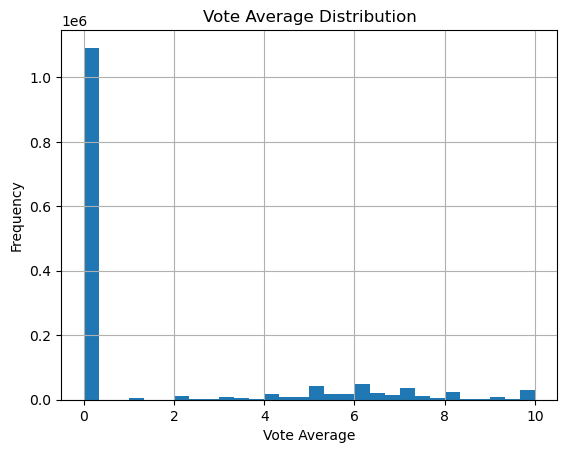

In [28]:
# how to plot the graph in pandas ?
df['vote_average'].hist(bins=30)
plt.title("Vote Average Distribution")
plt.xlabel("Vote Average")
plt.ylabel("Frequency")
plt.show()

<Axes: >

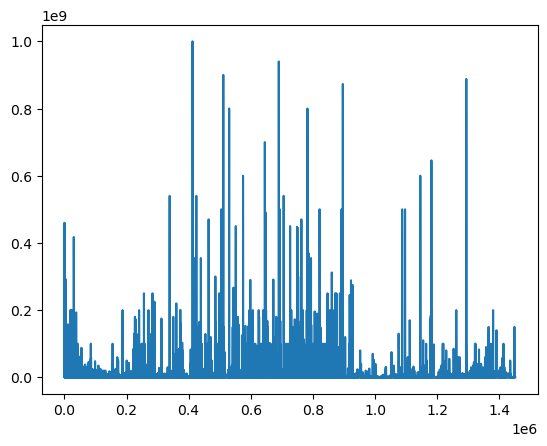

In [29]:
df['budget'].plot(kind='line')

<Axes: ylabel='count'>

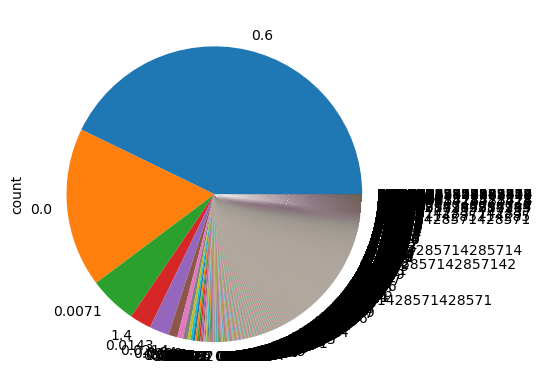

In [30]:
df['popularity'].value_counts().plot(kind='pie')